In [379]:
#install dependencies
%pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: 'pip install pandas': Expected semicolon (after name with no version specifier) or end
    pip install pandas
        ^ (from line 1 of requirements.txt)


In [380]:
#import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

In [381]:
# load and check data

df = pd.read_csv("cleaned_data.csv") # define dataframe
print(df.head())
print(df.describe())

   year  rank     country  life_eval  gdp_per_capita  social_support  \
0  2025     1     Finland      7.764           1.915           1.638   
1  2025     2     Iceland      7.540           1.971           1.720   
2  2025     3     Denmark      7.539           1.986           1.633   
3  2025     4  Costa Rica      7.439           1.697           1.483   
4  2025     5      Sweden      7.255           1.950           1.570   

   healthy_life_expectancy  freedom  generosity  corruption  dystopia_residual  
0                    0.939    1.105       0.093       0.491              1.582  
1                    0.996    1.105       0.187       0.187              1.373  
2                    0.930    1.081       0.125       0.474              1.310  
3                    0.739    1.101       0.059       0.122              2.236  
4                    1.027    1.070       0.149       0.447              1.041  
              year         rank    life_eval  gdp_per_capita  social_support  \
c

In [382]:
# research questions  
# 
# does money (GDP) correlate with happiness? with high-income countries, is the relationship linear or diminishing? 
# does generosity correlate with happiness? does it remain significant when accounting for other social, economic factors?
# what common characteristics define countries that consistently improve in happiness rankings over time, and what factors might explain these trends? 
# 

<Axes: >

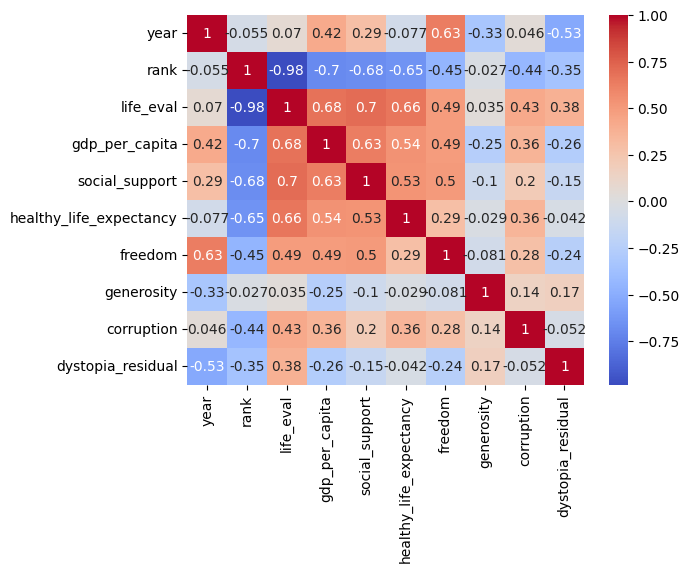

In [383]:
# all correlations

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")

<Axes: xlabel='gdp_per_capita', ylabel='life_eval'>

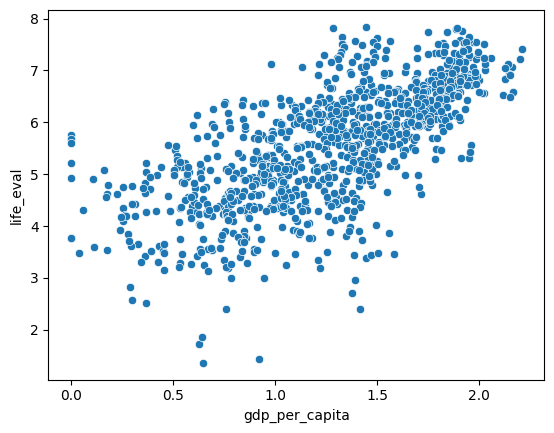

In [384]:
# GDP vs happiness
# does money (GDP) correlate with happiness? with high-income countries, is the relationship linear or diminishing? 

sns.scatterplot(data=df, x="gdp_per_capita", y="life_eval")

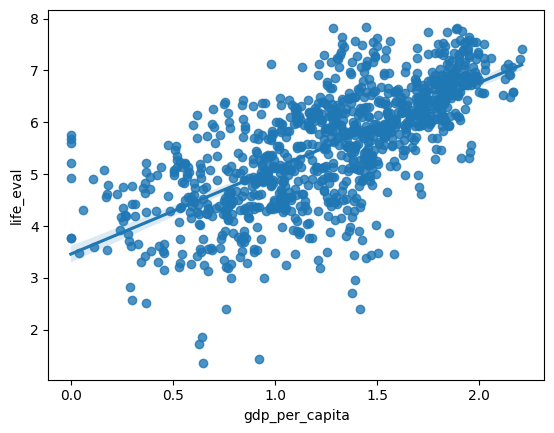

correlation:  0.6811744482032102


In [385]:
# test diminishing returns

sns.regplot(data=df, x="gdp_per_capita", y="life_eval")
plt.show()
print("correlation: ", df["gdp_per_capita"].corr(df["life_eval"]))

# there is a strong postive correlation between log(gdp) and happiness. since it is measured in log(gdp), we cannot determine if it will diminish

<Axes: xlabel='generosity', ylabel='life_eval'>

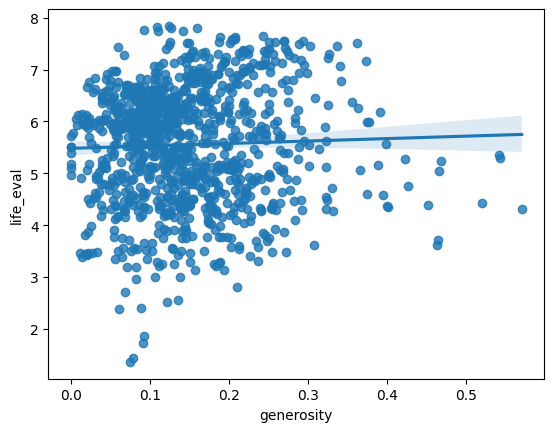

In [386]:
# generosity vs happiness
# does generosity correlate with happiness? does it remain significant when accounting for other social, economic factors?

sns.regplot(data = df, x="generosity", y="life_eval")

# from the graph, generosity shows a weak positive association with happiness

In [ ]:
# control for other variables

df_filtered = df[df["year"] > 2018]

# across all rows, only max 4 entries from each column is dropped so there will be neglible difference
#
#print(df_filtered.tail())
#print(df_filtered.isnull().sum())
df_filtered = df_filtered.dropna(subset=["gdp_per_capita"])
df_filtered = df_filtered.dropna(subset=["social_support"])
df_filtered = df_filtered.dropna(subset=["freedom"])
df_filtered = df_filtered.dropna(subset=["corruption"])
df_filtered = df_filtered.dropna(subset=["generosity"])

features = ["gdp_per_capita", "social_support", "freedom", "corruption", "generosity"]
X = df_filtered[features]
y = df_filtered["life_eval"]

scalar = StandardScaler()
X_scaled = scalar.fit_transform(df_filtered[features])

model = LinearRegression()
model.fit(X_scaled, y)

coef_df_scaled = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_
})

print(coef_df_scaled)

          feature  coefficient
0  gdp_per_capita     0.396657
1  social_support     0.479492
2         freedom     0.076394
3      corruption     0.193857
4      generosity     0.164302


In [388]:
# compare model performance with and without generosity

# with

y_pred = model.predict(X_scaled)
print(r2_score(y, y_pred))

0.651171789832662


In [ ]:
# without

features = ["gdp_per_capita", "social_support", "freedom", "corruption"]
X_scaled = scalar.fit_transform(df_filtered[features])

model = LinearRegression()
model.fit(X_scaled, y)
y_pred = model.predict(X_scaled)
print(r2_score(y, y_pred))

0.6327337000081306


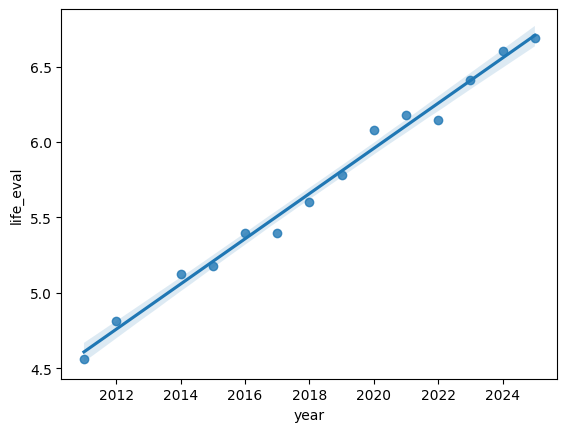

country:  Serbia


In [390]:
# countries improving over time
# what common characteristics define countries that consistently improve in happiness rankings over time, and what factors might explain these trends? 

# trend for one specific country

country_selected = "Serbia"
df_filtered = df[df["country"] == country_selected]
df_sorted = df_filtered.sort_values(["country", "year"])
sns.regplot(data=df_filtered, x="year", y="life_eval")

plt.show()
print("country: ", country_selected)

In [391]:
# rank by yearly change

df_sorted = df.sort_values(["country", "year"])
df_sorted["change"] = df_sorted.groupby("country")["life_eval"].diff()

# filter to reduce noise (with trade off in selection bias)
counts = df_sorted.groupby(by="country", dropna=True)["change"].count()
valid_countries = counts[counts >= 5].index # arbitrary 5
df_filtered = df_sorted[df_sorted["country"].isin(valid_countries)]

avg_change = df_filtered.groupby("country")["change"].mean()
avg_change_sorted = avg_change.sort_values(ascending=False)

top_countries = avg_change_sorted.head(10).index
bottom_countries = avg_change_sorted.tail(10).index

# top improvers
print(top_countries)

# worst decliners
print(bottom_countries)

Index(['Serbia', 'Bulgaria', 'Georgia', 'Latvia', 'Bosnia and Herzegovina',
       'Kosovo', 'Romania', 'China', 'Philippines', 'Mongolia'],
      dtype='str', name='country')
Index(['Botswana', 'Venezuela', 'Jordan', 'Lebanon', 'Malawi', 'Rwanda',
       'Turkmenistan', 'Somalia', 'Syria', 'Afghanistan'],
      dtype='str', name='country')


In [ ]:
# compare before vs after with other variables

selected_countries = top_countries.union(bottom_countries)

df_valid = df[df["country"].isin(valid_countries)]

temp = df_valid[df_valid["country"].isin(selected_countries)].sort_values(["country", "year"]).groupby("country").agg(
    life_eval_before=("life_eval", "first"),
    life_eval_after=("life_eval", "last"),
    gdp_before=("gdp_per_capita", "first"),
    gdp_after=("gdp_per_capita", "last"),
    social_support_before=("social_support", "first"),
    social_support_after=("social_support", "last"),
    healthy_life_expectancy_before=("healthy_life_expectancy", "first"),
    healthy_life_expectancy_after=("healthy_life_expectancy", "last"),
    freedom_before=("freedom", "first"),
    freedom_after=("freedom", "last"),
    generosity_before=("generosity", "first"),
    generosity_after=("generosity", "last"),
    corruption_before=("corruption", "first"),
    corruption_after=("corruption", "last"),
    dystopia_residual_before=("dystopia_residual", "first"),
    dystopia_residual_after=("dystopia_residual", "last")
)

before_after = temp.filter(like="_after") - temp.filter(like="_before").values
before_after.columns = [col.replace("_after", "_change") for col in before_after.columns]

print(before_after.sort_values(by="life_eval_change", ascending=False))

                        life_eval_change  gdp_change  social_support_change  \
country                                                                       
Serbia                             2.127       0.708                  0.216   
Bulgaria                           1.814       0.721                  0.126   
Georgia                            1.625       0.822                  0.470   
Latvia                             1.603       0.656                  0.196   
Bosnia and Herzegovina             1.524       0.698                  0.221   
Kosovo                             1.490       0.695                  0.109   
Romania                            1.451       0.698                  0.039   
China                              1.394       0.671                 -0.169   
Philippines                        1.381       0.638                  0.040   
Mongolia                           1.374       0.653                  0.156   
Somalia                           -0.932       0.283